In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import pickle
import scipy.sparse as sp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
tfidf = joblib.load("../Vectorización/tfidf_vectorizer.pkl")
X_train_tfidf = joblib.load("../Vectorización/X_train_tfidf.pkl")
X_test_tfidf = joblib.load("../Vectorización/X_test_tfidf.pkl")
y_train = joblib.load("../Vectorización/y_train.pkl")
y_test = joblib.load("../Vectorización/y_test.pkl")

### Regresión logistica + TF-IDF

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
logreg=LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)

In [5]:
logreg.fit(X_train_tfidf,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


In [6]:
from sklearn.metrics import classification_report

In [7]:
y_train_pred_rl = logreg.predict(X_train_tfidf)
y_test_pred_rl = logreg.predict(X_test_tfidf)

In [8]:
print("Train (RL+ TF-IDF)")
print(classification_report(y_train, y_train_pred_rl))
print("--------------------------------------------------")
print("test (RL+ TF-IDF)")
print(classification_report(y_test, y_test_pred_rl))

Train (RL+ TF-IDF)
              precision    recall  f1-score   support

          -1       0.83      0.80      0.82    637069
           1       0.81      0.83      0.82    637083

    accuracy                           0.82   1274152
   macro avg       0.82      0.82      0.82   1274152
weighted avg       0.82      0.82      0.82   1274152

--------------------------------------------------
test (RL+ TF-IDF)
              precision    recall  f1-score   support

          -1       0.81      0.78      0.80    159268
           1       0.79      0.81      0.80    159271

    accuracy                           0.80    318539
   macro avg       0.80      0.80      0.80    318539
weighted avg       0.80      0.80      0.80    318539



**Palabras más influyentes en la regresión logística**

In [9]:
coef_lr = logreg.coef_[0]
features = tfidf.get_feature_names_out()
top_n = 20


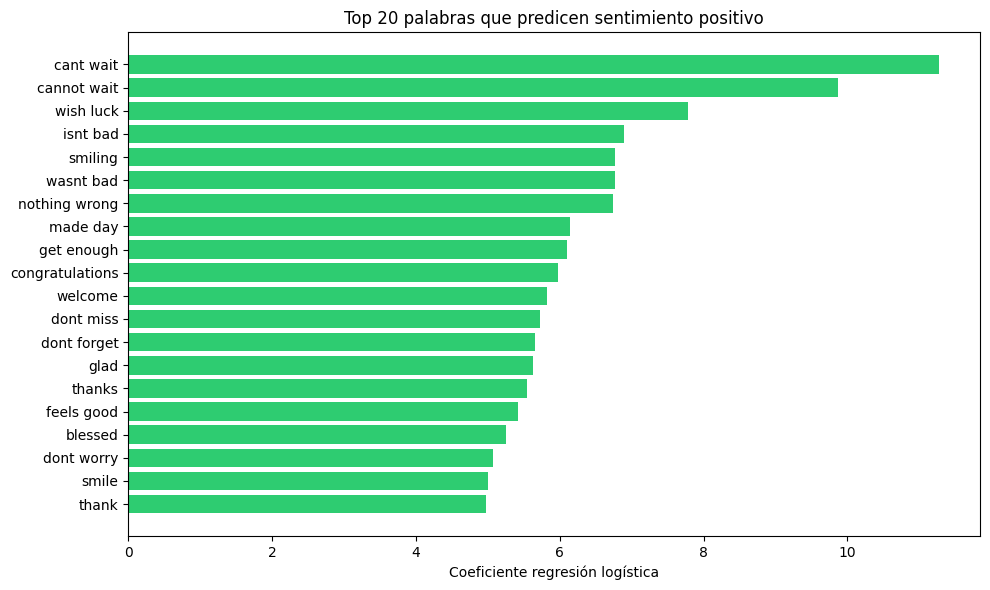

In [10]:
idx_pos = np.argsort(coef_lr)[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(features[idx_pos], coef_lr[idx_pos], color="#2ecc71")
plt.title("Top 20 palabras que predicen sentimiento positivo")
plt.xlabel("Coeficiente regresión logística")
plt.tight_layout()
plt.show()

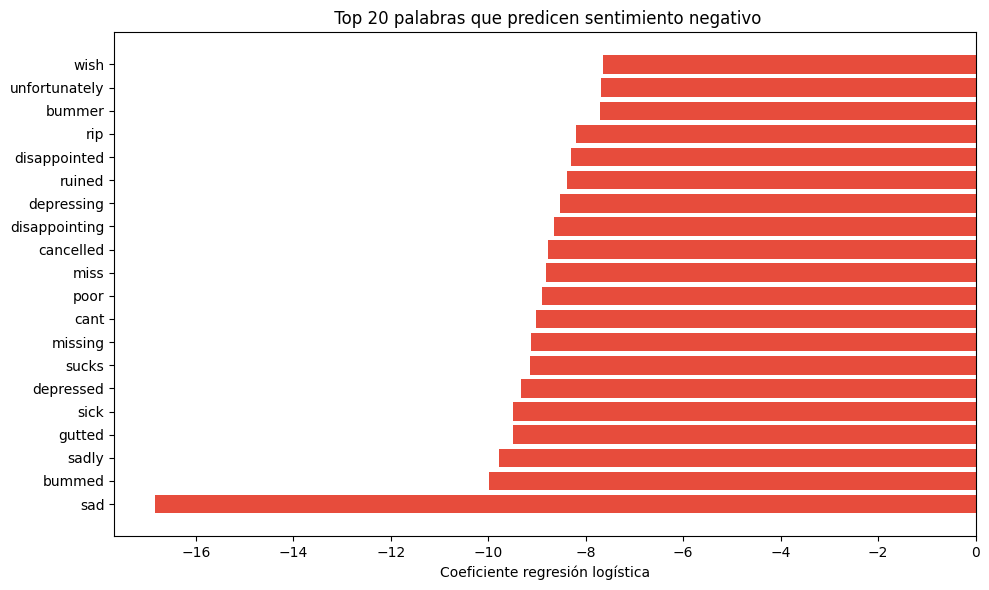

In [11]:
idx_neg = np.argsort(coef_lr)[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(features[idx_neg], coef_lr[idx_neg], color="#e74c3c")
plt.title(" Top 20 palabras que predicen sentimiento negativo")
plt.xlabel("Coeficiente regresión logística")
plt.tight_layout()
plt.show()

### Naive Bayes + BoW

In [12]:
#Cargamos los datos de Bow
bow = joblib.load("../Vectorización/bow_vectorizer.pkl")
X_train_bow = joblib.load("../Vectorización/X_train_bow.pkl")
X_test_bow  = joblib.load("../Vectorización/X_test_bow.pkl")

In [13]:
from sklearn.naive_bayes import MultinomialNB

In [14]:
nbayes_bow=MultinomialNB(alpha = 1.0)

In [15]:
nbayes_bow.fit(X_train_bow, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[637069.,637083.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[-1, 1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 47889)","[[113., 77., 41.,..., 12., 0., 8.], [ 69., 46., 26.,..., 27., 9., 12.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 47889)","[[-10.58,-10.96,-11.58,...,-12.75,-15.32,-13.12], [-11. ,-11.4 ,-11.96,...,-11.92,-12.95,-12.69]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,47889


In [16]:
y_train_pred_nbayes_bow = nbayes_bow.predict(X_train_bow)
y_test_pred_nbayes_bow  = nbayes_bow.predict(X_test_bow)

In [17]:
print("Train (Nbayes + Bow)")
print(classification_report(y_train, y_train_pred_nbayes_bow))
print("--------------------------------------------------")
print("test (Nbayes + Bow)")
print(classification_report(y_test, y_test_pred_nbayes_bow))

Train (Nbayes + Bow)
              precision    recall  f1-score   support

          -1       0.78      0.79      0.78    637069
           1       0.79      0.78      0.78    637083

    accuracy                           0.78   1274152
   macro avg       0.78      0.78      0.78   1274152
weighted avg       0.78      0.78      0.78   1274152

--------------------------------------------------
test (Nbayes + Bow)
              precision    recall  f1-score   support

          -1       0.77      0.78      0.77    159268
           1       0.77      0.77      0.77    159271

    accuracy                           0.77    318539
   macro avg       0.77      0.77      0.77    318539
weighted avg       0.77      0.77      0.77    318539



**Palabras más influyentes en Naive Bayes**

In [18]:
# Extracción de log-probabilidades condicionales y cálculo del Log-Odds Ratio
print(nbayes_bow.classes_)
log_prob_neg = nbayes_bow.feature_log_prob_[0]
log_prob_pos = nbayes_bow.feature_log_prob_[1]
coef_nb = log_prob_pos - log_prob_neg

# Mapeo del vocabulario indexado BoW
features = bow.get_feature_names_out()
top_n = 20

[-1  1]


In [19]:
#Filtramos términos con baja frecuencia, el log-odds
min_count = 40
word_counts = np.asarray(X_train_bow.sum(axis=0)).ravel()
mask = word_counts >= min_count


features_filtrado = features[mask]          
coef_nb_filtrado = coef_nb[mask]          

print("Términos totales filtrados:", len(features_filtrado))
                    

Términos totales filtrados: 12539


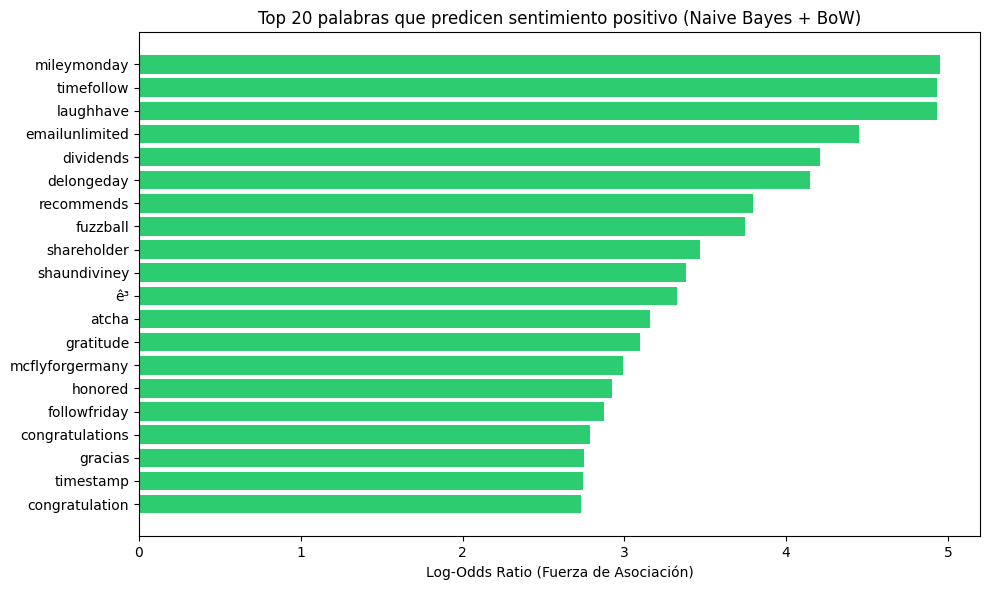

In [20]:
# Obtención de índices mediante ordenamiento con argsort sobre los datos filtrados
idx_pos = np.argsort(coef_nb_filtrado)[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(features_filtrado[idx_pos], coef_nb_filtrado[idx_pos], color="#2ecc71")
plt.title("Top 20 palabras que predicen sentimiento positivo (Naive Bayes + BoW)")
plt.xlabel("Log-Odds Ratio (Fuerza de Asociación)")
plt.tight_layout()
plt.show()

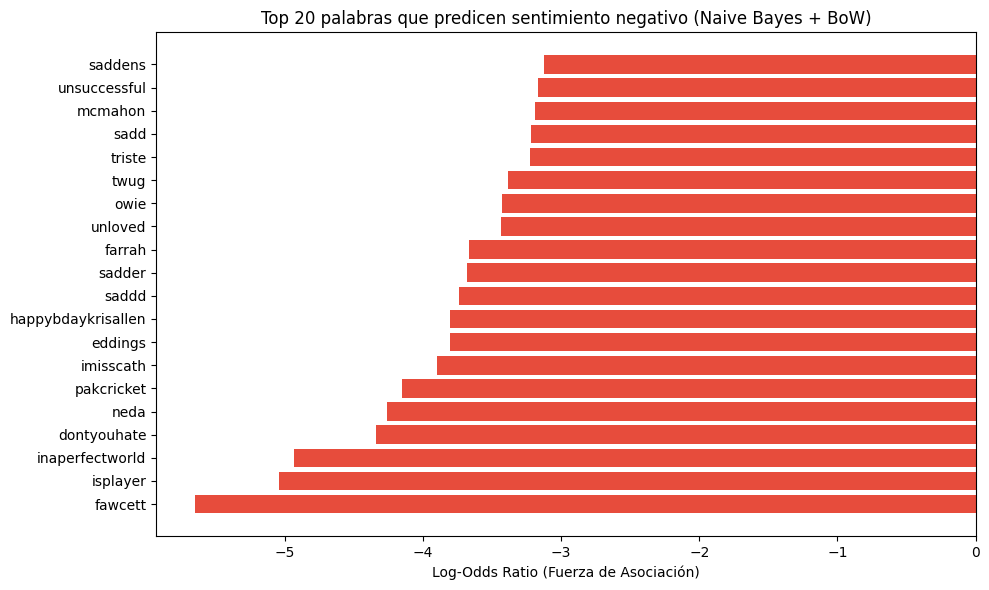

In [21]:
# Obtenemos los índices con los valores más bajos usando argsort sobre los datos filtrados
idx_neg = np.argsort(coef_nb_filtrado)[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(features_filtrado[idx_neg], coef_nb_filtrado[idx_neg], color="#e74c3c")
plt.title("Top 20 palabras que predicen sentimiento negativo (Naive Bayes + BoW)")
plt.xlabel("Log-Odds Ratio (Fuerza de Asociación)")
plt.tight_layout()
plt.show()

**Comparación RL + TF-IDF vs NB + bow

In [22]:
print("----------------------------------------------")
print("Comparación RL + TF-IDF vs NB + bow")
print("----------------------------------------------")
print("--- TRAIN Accuracy ---")
print("RL + TF-IDF:", logreg.score(X_train_tfidf, y_train))
print("NB + BoW       :", nbayes_bow.score(X_train_bow, y_train))

print("--- TEST Accuracy ---")
print("RL + TF-IDF:", logreg.score(X_test_tfidf, y_test))
print("NB + BoW       :", nbayes_bow.score(X_test_bow, y_test))
print("|---------------------------------------------|")


----------------------------------------------
Comparación RL + TF-IDF vs NB + bow
----------------------------------------------
--- TRAIN Accuracy ---
RL + TF-IDF: 0.8184313959402018
NB + BoW       : 0.7838107227395161
--- TEST Accuracy ---
RL + TF-IDF: 0.7987499175925082
NB + BoW       : 0.7725396262310109
|---------------------------------------------|


In [23]:
import os
os.makedirs("../Modelos", exist_ok=True)
#Guardamos ambos modelos
joblib.dump(logreg, "../Modelos/logreg_tfidf.pkl")
joblib.dump(nbayes_bow, "../Modelos/nbayes_bow.pkl")

['../Modelos/nbayes_bow.pkl']

### Modelo preentrenado Textblob

In [24]:
!pip install textblob
!python -m textblob.download_corpora

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [25]:
from textblob import TextBlob
from sklearn.model_selection import train_test_split

In [26]:
df_limpio=pd.read_csv("../Preprocesamiento/training_limpio.csv")
X_train_original, X_test_original, y_train_check, y_test_check = train_test_split( df_limpio["text"], df_limpio["sentiment"], test_size=0.2, random_state=42, stratify=df_limpio["sentiment"])

In [27]:
def textblob_predict(texto):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > 0:
        return 1     
    else:
        return -1     

# Textblob clasificará polaridad=0 (neutral) como negativo. 
#Es una decisión deliberada para forzar una clasificación binaria

In [28]:
y_train_pred_textblob = np.array([textblob_predict(t) for t in X_train_original])
y_test_pred_textblob  = np.array([textblob_predict(t) for t in X_test_original])

In [29]:
print("Train (TextBlob)")
print(classification_report(y_train_check, y_train_pred_textblob))
print("--------------------------------------------------")
print("Test (TextBlob)")
print(classification_report(y_test_check, y_test_pred_textblob))

Train (TextBlob)
              precision    recall  f1-score   support

          -1       0.61      0.69      0.65    637069
           1       0.64      0.56      0.60    637083

    accuracy                           0.62   1274152
   macro avg       0.63      0.62      0.62   1274152
weighted avg       0.63      0.62      0.62   1274152

--------------------------------------------------
Test (TextBlob)
              precision    recall  f1-score   support

          -1       0.61      0.68      0.65    159268
           1       0.64      0.56      0.60    159271

    accuracy                           0.62    318539
   macro avg       0.63      0.62      0.62    318539
weighted avg       0.63      0.62      0.62    318539



In [30]:
print("----------------------------------------------")
print("Comparación RL + TF-IDF vs NB + BoW vs TextBlob")
print("----------------------------------------------")

accu_rl = logreg.score(X_test_tfidf, y_test)
accu_nb = nbayes_bow.score(X_test_bow, y_test)
accu_tb = (y_test_pred_textblob == y_test.values).mean()

comparacion = pd.DataFrame({"Modelo": ["RL + TF-IDF", "NB + BoW", "TextBlob"], "Accuracy": [accu_rl, accu_nb, accu_tb]})

display(comparacion)

----------------------------------------------
Comparación RL + TF-IDF vs NB + BoW vs TextBlob
----------------------------------------------


,Modelo,Accuracy
0,RL + TF-IDF,0.798750
1,NB + BoW,0.772540
2,TextBlob,0.623214


In [31]:
joblib.dump(accu_tb, "../Modelos/textblob_accuracy.pkl")

['../Modelos/textblob_accuracy.pkl']